# GA-033 -- Introdução ao `fempack` e workflow FEM 2D (Q1 em quadriláteros)

Este notebook mostra o *workflow completo* usando o pacote `fempack`:

1. Definir o problema modelo de Poisson 2D com solução exata (MMS).
2. Construir uma malha estruturada do quadrado unitário.
3. Definir o espaço de elementos finitos `FunctionSpace`.
4. Montar matriz de rigidez e vetor de carga.
5. Impor condições de Dirichlet.
6. Resolver o sistema linear.
7. Calcular erros em normas $L^2$ e $H^1$.
8. Estudar a convergência com refinamento de malha.

Nesta aula vamos usar **elementos Q1 em quadriláteros** (`cell_type="square"`),
que já estão totalmente implementados no `fempack`. O assignment usará
elementos **P1 em triângulos**, que você irá completar.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt

from fempack.mesh import Mesh
from fempack.spaces import FunctionSpace
from fempack.assemble import assemble_stiffness, assemble_load
from fempack.bcs import apply_dirichlet
from fempack.solvers import solve_direct
from fempack.verification import l2_h1_errors

## Problema modelo (Poisson 2D com MMS)

Vamos resolver o problema

$$
-\Delta u = f \quad \text{em } \Omega = (0,1)^2, \qquad
u = g \quad \text{em } \partial\Omega,
$$

com solução exata

$$
u_{\text{ex}}(x,y) = \sin(\pi x)\,\sin(\pi y).
$$

Então

$$
f(x,y) = -\Delta u_{\text{ex}}(x,y)
= 2\pi^2\,\sin(\pi x)\,\sin(\pi y),
\qquad
g(x,y) = u_{\text{ex}}(x,y).
$$

In [2]:
def u_exact_2d(x: float, y: float) -> float:
    """Exact solution u(x, y) = sin(pi x) sin(pi y)."""
    return float(np.sin(np.pi * x) * np.sin(np.pi * y))


def grad_u_exact_2d(x: float, y: float) -> np.ndarray:
    """Exact gradient of u_exact_2d as a length-2 array.

    ∂u/∂x = π cos(π x) sin(π y)
    ∂u/∂y = π sin(π x) cos(π y)
    """
    du_dx = np.pi * np.cos(np.pi * x) * np.sin(np.pi * y)
    du_dy = np.pi * np.sin(np.pi * x) * np.cos(np.pi * y)
    return np.array([du_dx, du_dy], dtype=float)


def f_rhs_2d(x: float, y: float) -> float:
    """Right-hand side f(x, y) = 2 π² sin(π x) sin(π y)."""
    return float(2.0 * np.pi**2 * np.sin(np.pi * x) * np.sin(np.pi * y))

## Explorando o `fempack`: malha e espaço de funções

Vamos começar construindo uma malha de quadriláteros Q1 no quadrado unitário
e criando o espaço de elementos finitos correspondente.

In [3]:
# Malha Q1: quadrado unitário dividido em nx × ny quadriláteros
nx = ny = 4
mesh = Mesh.unit_square_quadrilateral(nx, ny)

print("Mesh:")
print(f"  cell_type   = {mesh.cell_type}")
print(f"  num_vertices = {mesh.num_vertices}")
print(f"  num_cells    = {mesh.num_cells}")
print(f"  coords.shape = {mesh.coords.shape}")
print(f"  cells.shape  = {mesh.cells.shape}")

# Espaço de elementos finitos: Lagrange Q1 em quadriláteros
V = FunctionSpace(mesh, family="Lagrange", degree=1)
print("\nFunctionSpace:")
print(f"  dim   = {V.dim}")
print(f"  ndofs = {V.ndofs}")

Mesh:
  cell_type   = square
  num_vertices = 25
  num_cells    = 16
  coords.shape = (25, 2)
  cells.shape  = (16, 4)

FunctionSpace:
  dim   = 2
  ndofs = 25


### Visualizando a malha

Uma visualização rápida ajuda a conectar a conectividade (`cells`) com a geometria (`coords`).

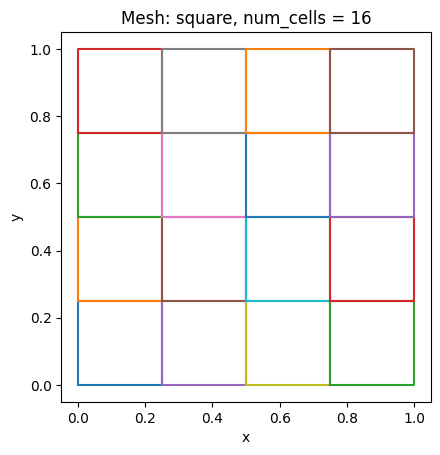

In [4]:
def plot_mesh(mesh: Mesh) -> None:
    """Plot simples da malha (triângulos ou quadriláteros)."""
    coords = mesh.coords
    cells = mesh.cells

    fig, ax = plt.subplots()
    if mesh.cell_type in ("square", "triangle"):
        for cell in cells:
            vertices = coords[list(cell) + [cell[0]], :]
            ax.plot(vertices[:, 0], vertices[:, 1], "-")
    else:
        raise ValueError(f"Plot não implementado para cell_type={mesh.cell_type!r}")

    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Mesh: {mesh.cell_type}, num_cells = {mesh.num_cells}")
    plt.show()


plot_mesh(mesh)

## Montagem: matriz de rigidez e vetor de carga

Nesta etapa, o `fempack` faz por você o que fizemos “na mão”:

- loop sobre elementos;
- cálculo das matrizes locais (via funções em `fempack.local`);
- espalhamento (scatter) para a matriz global em formato esparso.

Vamos montar a matriz de rigidez e o vetor de carga para o problema de Poisson.

In [5]:
# Reusar a malha e o espaço construídos acima
quad_order = 2  # ordem da quadratura em cada quadrilátero

A = assemble_stiffness(V)
b = assemble_load(V, f_rhs_2d, quad_order=quad_order)

print("Stiffness matrix A:")
print(f"  shape = {A.shape}")
print(f"  nnz   = {A.nnz}")

print("\nLoad vector b:")
print(f"  shape = {b.shape}")

Stiffness matrix A:
  shape = (25, 25)
  nnz   = 169

Load vector b:
  shape = (25,)


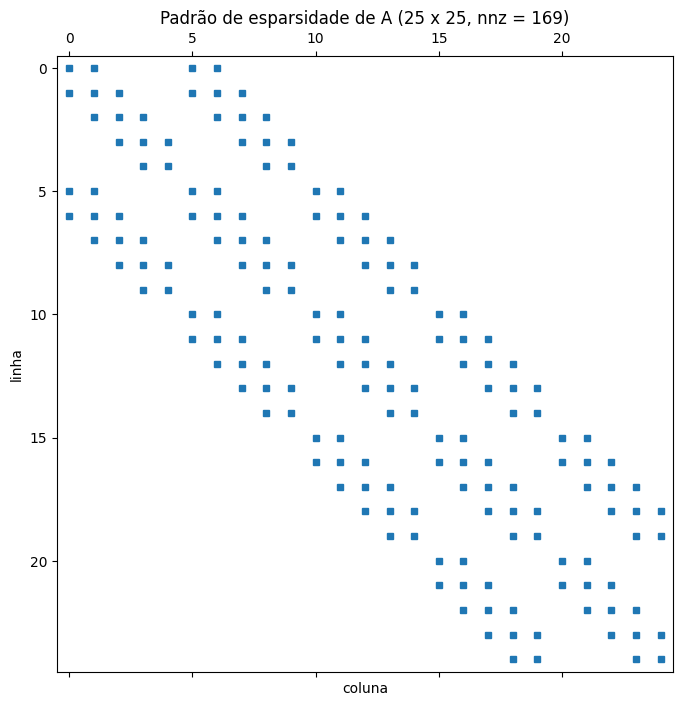

In [6]:
# Visualizar o padrão de esparsidade da matriz A
fig, ax = plt.subplots(figsize=(8, 8))
ax.spy(A, markersize=5)
ax.set_title(f"Padrão de esparsidade de A ({A.shape[0]} x {A.shape[1]}, nnz = {A.nnz})")
ax.set_xlabel("coluna")
ax.set_ylabel("linha")
plt.show()

## Condições de Dirichlet e solução do sistema linear

Usamos `apply_dirichlet` para impor **u = u_ex** na borda do domínio:

1. Ajusta o lado direito para condições não homogêneas.
2. Zera linhas/colunas de nós de Dirichlet e coloca 1 na diagonal.
3. Retorna `A_bc`, `b_bc`, prontos para resolver.

Depois usamos `solve_direct` para resolver o sistema linear.

In [7]:
# Impor Dirichlet em todos os nós de fronteira: u = u_exact_2d
A_bc, b_bc = apply_dirichlet(A, b, V, g=u_exact_2d)

uh = solve_direct(A_bc, b_bc)
print("Solution vector uh:")
print(f"  shape = {uh.shape}")
print(f"  min(uh) = {uh.min():.3e}")
print(f"  max(uh) = {uh.max():.3e}")

Solution vector uh:
  shape = (25,)
  min(uh) = 0.000e+00
  max(uh) = 1.053e+00


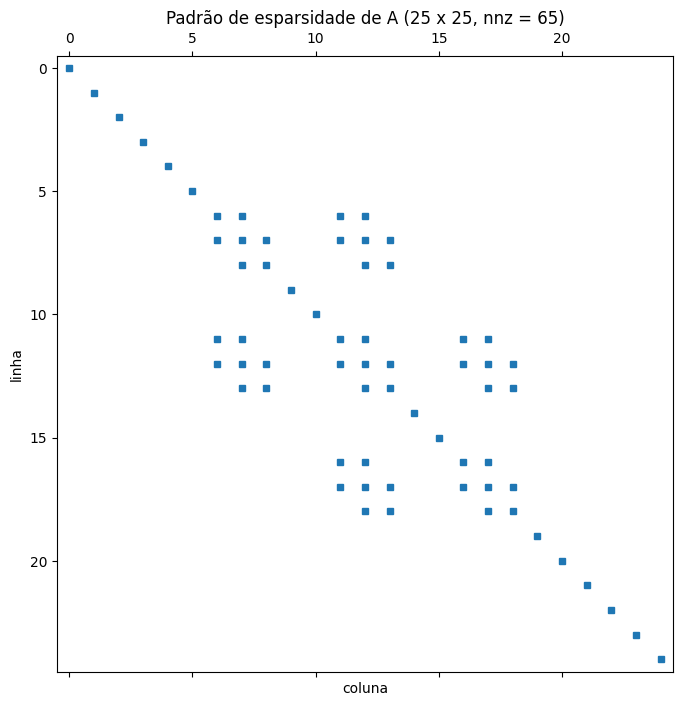

In [8]:
# Visualizar o padrão de esparsidade da matriz A_bc
fig, ax = plt.subplots(figsize=(8, 8))
ax.spy(A_bc, markersize=5)
ax.set_title(
    f"Padrão de esparsidade de A ({A_bc.shape[0]} x {A_bc.shape[1]}, nnz = {A_bc.nnz})"
)
ax.set_xlabel("coluna")
ax.set_ylabel("linha")
plt.show()

### Visualizando a solução aproximada

Podemos fazer um ‘scatter’ dos valores de `uh` nos nós para ter uma ideia da solução
antes de falar de erro e convergência.

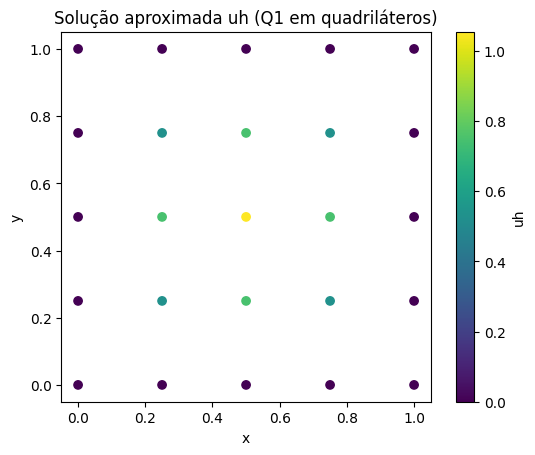

In [9]:
def plot_solution_scatter(mesh: Mesh, uh: np.ndarray, title: str = "uh") -> None:
    """Scatter dos valores nodais da solução aproximada."""
    coords = mesh.coords
    fig, ax = plt.subplots()
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=uh)
    fig.colorbar(sc, ax=ax, label="uh")
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    plt.show()


plot_solution_scatter(mesh, uh, title="Solução aproximada uh (Q1 em quadriláteros)")

Ou um plot de "contorno":

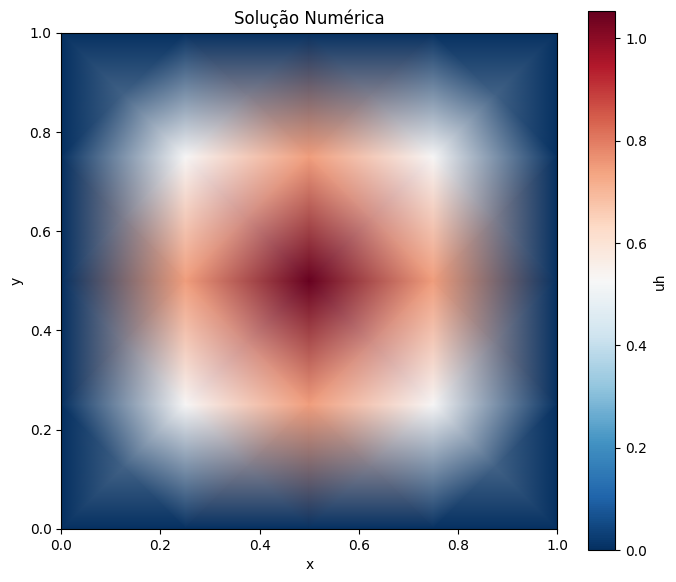

In [10]:
def plot_solution_tripcolor(mesh: Mesh, uh: np.ndarray, title: str = "uh") -> None:
    """Gráfico de cores interpoladas da solução aproximada."""
    coords = mesh.coords

    fig, ax = plt.subplots(figsize=(8, 7))

    if mesh.cell_type == "square":
        # Para malhas estruturadas de quadriláteros, usar pcolormesh
        # Reconstruir a grade estruturada
        x_unique = np.unique(coords[:, 0])
        y_unique = np.unique(coords[:, 1])
        nx_nodes = len(x_unique)
        ny_nodes = len(y_unique)

        # Criar arrays 2D para X, Y e uh
        X = coords[:, 0].reshape(ny_nodes, nx_nodes)
        Y = coords[:, 1].reshape(ny_nodes, nx_nodes)
        U = uh.reshape(ny_nodes, nx_nodes)

        # Plotar com pcolormesh (interpolação suave)
        pc = ax.pcolormesh(X, Y, U, shading="gouraud", cmap="RdBu_r")

    elif mesh.cell_type == "triangle":
        # Para malhas não estruturadas, usar tripcolor
        from matplotlib.tri import Triangulation

        x = coords[:, 0]
        y = coords[:, 1]
        triang = Triangulation(x, y, mesh.cells)
        pc = ax.tripcolor(triang, uh, shading="gouraud", cmap="RdBu_r")

    else:
        raise ValueError(f"Plot não implementado para cell_type={mesh.cell_type!r}")

    fig.colorbar(pc, ax=ax, label="uh")
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    plt.show()


plot_solution_tripcolor(mesh, uh, title="Solução Numérica")

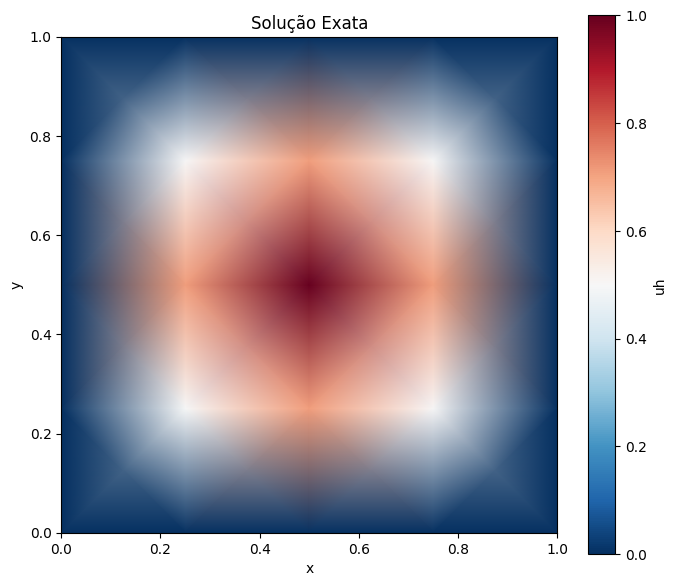

In [11]:
# Plotar a solução exata nos mesmos pontos
coords = mesh.coords
u_ex = np.array([u_exact_2d(x, y) for x, y in coords])

plot_solution_tripcolor(mesh, u_ex, title="Solução Exata")

## Cálculo de erros em $L^2$ e $H^1$

O módulo `fempack.verification` fornece a função `l2_h1_errors`, que já implementa:

- quadratura em cada célula (triângulo ou quadrilátero),
- reconstrução da solução aproximada `uh` no interior dos elementos,
- integração de $(u - u_h)^2$ e $|\nabla u - \nabla u_h|^2$.

Aqui vamos chamar com `cell_type="square"` para elementos Q1 em quadriláteros.

In [12]:
eL2, eH1 = l2_h1_errors(
    coords=mesh.coords,
    cells=mesh.cells,
    uh=uh,
    u_exact=u_exact_2d,
    grad_u_exact=grad_u_exact_2d,
    cell_type="square",
    order=quad_order,
)

print(f"Erros para nx=ny={nx}:")
print(f"  ||e||_L2  = {eL2:.6e}")
print(f"  |e|_H1    = {eH1:.6e}")

Erros para nx=ny=4:
  ||e||_L2  = 2.552469e-02
  |e|_H1    = 4.996539e-01


## Encapsulando o workflow em uma função

Agora vamos colocar todo o workflow dentro de uma função
`solve_poisson_q1(nx, ny, quad_order=2)`, que:

1. Cria a malha e o espaço `FunctionSpace`.
2. Monta `A` e `b`.
3. Impõe Dirichlet com `apply_dirichlet`.
4. Resolve o sistema linear.
5. Calcula e retorna erros $L^2$ e $H^1$.


In [13]:
def solve_poisson_q1(
    nx: int,
    ny: int,
    quad_order: int = 2,
    verbose: bool = True,
) -> tuple[float, float, float]:
    """Solve the 2D Poisson MMS problem using Q1 elements on a square mesh.

    Parameters
    ----------
    nx, ny :
        Number of cells in the x and y directions.
    quad_order :
        Quadrature order used in assemble_load and error computation.
    verbose :
        If True, prints a summary of h and errors.

    Returns
    -------
    h :
        Mesh size parameter, here taken as h = 1 / nx.
    eL2 :
        L2-norm of the error.
    eH1 :
        H1-seminorm of the error.
    """
    mesh = Mesh.unit_square_quadrilateral(nx, ny)
    V = FunctionSpace(mesh, family="Lagrange", degree=1)

    A = assemble_stiffness(V)
    b = assemble_load(V, f_rhs_2d, quad_order=quad_order)
    A_bc, b_bc = apply_dirichlet(A, b, V, g=u_exact_2d)
    uh = solve_direct(A_bc, b_bc)

    eL2, eH1 = l2_h1_errors(
        coords=mesh.coords,
        cells=mesh.cells,
        uh=uh,
        u_exact=u_exact_2d,
        grad_u_exact=grad_u_exact_2d,
        cell_type="square",
        order=quad_order,
    )

    h = 1.0 / nx
    if verbose:
        print(f"nx=ny={nx:3d}: h = {h:.3e}, ||e||_L2 = {eL2:.3e}, |e|_H1 = {eH1:.3e}")
    return h, eL2, eH1

### Testando a função em uma única malha

Vamos apenas conferir se tudo funciona para uma malha moderada, por exemplo
$8 \times 8$ quadriláteros.

In [14]:
h_test, eL2_test, eH1_test = solve_poisson_q1(8, 8, quad_order=2)

nx=ny=  8: h = 1.250e-01, ||e||_L2 = 6.413e-03, |e|_H1 = 2.513e-01


## Estudo de convergência com refinamento de malha

Agora fazemos um loop em malhas cada vez mais refinadas e medimos:

- $h = 1/n_x$,
- $\|e\|_{L^2(\Omega)}$,
- $|e|_{H^1(\Omega)}$,

e estimamos as ordens de convergência experimentais:

$$
p_{L^2} \approx \frac{\log(e_{L^2}(h_1) / e_{L^2}(h_2))}{\log(h_1 / h_2)},
\quad
p_{H^1} \approx \frac{\log(e_{H^1}(h_1) / e_{H^1}(h_2))}{\log(h_1 / h_2)}.
$$

In [15]:
Ns = [4, 8, 16, 32]
results: list[tuple[float, float, float]] = []

for N in Ns:
    h, eL2, eH1 = solve_poisson_q1(N, N, quad_order=2, verbose=True)
    results.append((h, eL2, eH1))

hs = np.array([r[0] for r in results])
eL2s = np.array([r[1] for r in results])
eH1s = np.array([r[2] for r in results])

print("\nTabela de erros:")
print("   h         ||e||_L2        |e|_H1")
for h, eL2, eH1 in results:
    print(f"{h:8.3e}  {eL2:11.3e}  {eH1:11.3e}")

nx=ny=  4: h = 2.500e-01, ||e||_L2 = 2.552e-02, |e|_H1 = 4.997e-01
nx=ny=  8: h = 1.250e-01, ||e||_L2 = 6.413e-03, |e|_H1 = 2.513e-01
nx=ny= 16: h = 6.250e-02, ||e||_L2 = 1.606e-03, |e|_H1 = 1.258e-01
nx=ny= 32: h = 3.125e-02, ||e||_L2 = 4.015e-04, |e|_H1 = 6.295e-02

Tabela de erros:
   h         ||e||_L2        |e|_H1
2.500e-01    2.552e-02    4.997e-01
1.250e-01    6.413e-03    2.513e-01
6.250e-02    1.606e-03    1.258e-01
3.125e-02    4.015e-04    6.295e-02


In [16]:
def experimental_orders(hs: np.ndarray, errs: np.ndarray) -> np.ndarray:
    """Compute experimental convergence rates between successive meshes."""
    ratios = errs[:-1] / errs[1:]
    h_ratios = hs[:-1] / hs[1:]
    return np.log(ratios) / np.log(h_ratios)


pL2 = experimental_orders(hs, eL2s)
pH1 = experimental_orders(hs, eH1s)

print("Ordens experimentais (entre malhas sucessivas):")
for i in range(len(pL2)):
    print(
        f"h_{i}={hs[i]:.3e} → h_{i+1}={hs[i+1]:.3e}: "
        f"p_L2 ≈ {pL2[i]:.3f}, p_H1 ≈ {pH1[i]:.3f}"
    )

Ordens experimentais (entre malhas sucessivas):
h_0=2.500e-01 → h_1=1.250e-01: p_L2 ≈ 1.993, p_H1 ≈ 0.992
h_1=1.250e-01 → h_2=6.250e-02: p_L2 ≈ 1.998, p_H1 ≈ 0.998
h_2=6.250e-02 → h_3=3.125e-02: p_L2 ≈ 1.999, p_H1 ≈ 0.999


### Gráfico log-log dos erros

Um gráfico log-log ajuda a visualizar se as curvas seguem as inclinações
esperadas:

- $\|e\|_{L^2} \sim h^2$ para P1/Q1;
- $|e|_{H^1} \sim h$.

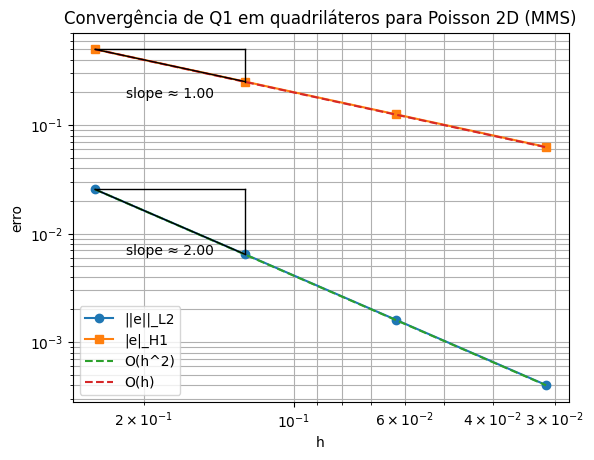

In [17]:
fig, ax = plt.subplots()

ax.loglog(hs, eL2s, "o-", label="||e||_L2")
ax.loglog(hs, eH1s, "s-", label="|e|_H1")

# Retas de referência ~ h^2 e ~ h
h_ref = hs
L2_ref = eL2s[0] * (h_ref / h_ref[0]) ** 2
H1_ref = eH1s[0] * (h_ref / h_ref[0])

ax.loglog(h_ref, L2_ref, "--", label="O(h^2)")
ax.loglog(h_ref, H1_ref, "--", label="O(h)")

# Abaixo vamos adicionar triângulos com a inclinação
# correspondente às taxas de convergência

# Triângulo para L2 (slope ≈ 2)
slope_L2 = pL2.mean()
h1_L2, h2_L2 = hs[0], hs[1]
e1_L2, e2_L2 = eL2s[0], eL2s[1]
# Desenhar triângulo
ax.plot([h1_L2, h2_L2], [e1_L2, e1_L2], "k-", linewidth=1)  # ponto 1
ax.plot([h2_L2, h2_L2], [e1_L2, e2_L2], "k-", linewidth=1)  # ponto 2
ax.plot([h1_L2, h2_L2], [e1_L2, e2_L2], "k-", linewidth=1)  # ponto 3
# Adicionar texto com a inclinação
mid_x_L2 = np.sqrt(h1_L2 * h2_L2)
mid_y_L2 = np.sqrt(e1_L2 * e2_L2)
ax.text(mid_x_L2, mid_y_L2 * 0.5, f"slope ≈ {slope_L2:.2f}", fontsize=10, ha="center")

# Triângulo para H1 (slope ≈ 1)
slope_H1 = pH1.mean()
h1_H1, h2_H1 = hs[0], hs[1]
e1_H1, e2_H1 = eH1s[0], eH1s[1]
# Desenhar triângulo
ax.plot([h1_H1, h2_H1], [e1_H1, e1_H1], "k-", linewidth=1)
ax.plot([h2_H1, h2_H1], [e1_H1, e2_H1], "k-", linewidth=1)
ax.plot([h1_H1, h2_H1], [e1_H1, e2_H1], "k-", linewidth=1)
# Adicionar texto com a inclinação
mid_x_H1 = np.sqrt(h1_H1 * h2_H1)
mid_y_H1 = np.sqrt(e1_H1 * e2_H1)
ax.text(mid_x_H1, mid_y_H1 * 0.5, f"slope ≈ {slope_H1:.2f}", fontsize=10, ha="center")

ax.invert_xaxis()
ax.set_xlabel("h")
ax.set_ylabel("erro")
ax.set_title("Convergência de Q1 em quadriláteros para Poisson 2D (MMS)")
ax.legend()
ax.grid(True, which="both")
plt.show()

## Conectando com o código-fonte do `fempack`

Para entender melhor a implementação, é interessante olhar algumas
funções chave:

- `Mesh.unit_square_quadrilateral` em `fempack.mesh`;
- `LagrangeElement` em `fempack.elements`;
- `local_stiffness_q1_square` e `local_load_q1_square` em `fempack.local`;
- `assemble_stiffness` e `assemble_load` em `fempack.assemble`;
- `l2_h1_errors` em `fempack.verification`.

Você pode inspecionar essas funções diretamente no notebook usando `inspect`:

```python
import inspect
import fempack.local as local
import fempack.reference as reference

print(inspect.getsource(local.local_stiffness_q1_square))
```

ou então abrir os arquivos `.py` no editor (VSCode, etc.) e ir ligando o
código com o que fizemos “na mão” em sala.

---

**Resumo da aula prática**:

1. Apresentamos a API básica do `fempack` (malha, espaço, montagem, BCs, solver).
2. Resolvemos um problema de Poisson 2D com solução exata usando Q1 em quadriláteros.
3. Medimos erros em $L^2$ e $H^1$ e verificamos as ordens de convergência.
4. Conectamos esses passos com as funções chave do código.

No assignment, você vai repetir esse workflow usando elementos P1 em triângulos,
implementando as partes que estão marcadas com `TODO`.
